<a href="https://colab.research.google.com/github/maria-giuliari/Sistema-Cardapio-Semanal/blob/main/codigograficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fluxograma – Fluxo Principal do Usuário

In [1]:
!pip install graphviz

from graphviz import Digraph

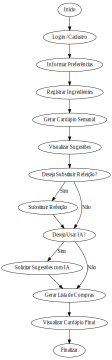

In [2]:
fluxo = Digraph(comment='Fluxo Principal do Usuário')

fluxo.attr(rankdir='TB', size='8,5')

# Nós
fluxo.node('A', 'Início')
fluxo.node('B', 'Login / Cadastro')
fluxo.node('C', 'Informar Preferências')
fluxo.node('D', 'Registrar Ingredientes')
fluxo.node('E', 'Gerar Cardápio Semanal')
fluxo.node('F', 'Visualizar Sugestões')
fluxo.node('G', 'Deseja Substituir Refeição?')
fluxo.node('H', 'Substituir Refeição')
fluxo.node('I', 'Deseja Usar IA?')
fluxo.node('J', 'Solicitar Sugestões com IA')
fluxo.node('K', 'Gerar Lista de Compras')
fluxo.node('L', 'Visualizar Cardápio Final')
fluxo.node('M', 'Finalizar')

# Fluxo Principal
fluxo.edge('A', 'B')
fluxo.edge('B', 'C')
fluxo.edge('C', 'D')
fluxo.edge('D', 'E')
fluxo.edge('E', 'F')
fluxo.edge('F', 'G')

# Decisão 1
fluxo.edge('G', 'H', label='Sim')
fluxo.edge('G', 'I', label='Não')
fluxo.edge('H', 'I')

# Decisão 2
fluxo.edge('I', 'J', label='Sim')
fluxo.edge('I', 'K', label='Não')
fluxo.edge('J', 'K')

# Final
fluxo.edge('K', 'L')
fluxo.edge('L', 'M')

fluxo.render('fluxograma_fluxo_principal', view=True)
fluxo

# Diagrama de Atividades – Fluxo Principal do Usuário

In [3]:
from graphviz import Digraph

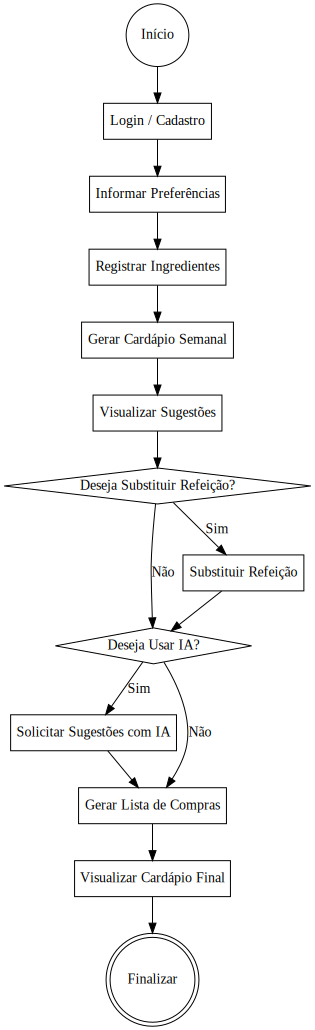

In [4]:
atividade = Digraph('DiagramaAtividades')

atividade.attr(rankdir='TB')

# Nós principais
atividade.node('inicio', 'Início', shape='circle')
atividade.node('login', 'Login / Cadastro', shape='box')
atividade.node('preferencias', 'Informar Preferências', shape='box')
atividade.node('ingredientes', 'Registrar Ingredientes', shape='box')
atividade.node('gerar', 'Gerar Cardápio Semanal', shape='box')
atividade.node('visualizar', 'Visualizar Sugestões', shape='box')

# Decisões
atividade.node('decisao1', 'Deseja Substituir Refeição?', shape='diamond')
atividade.node('decisao2', 'Deseja Usar IA?', shape='diamond')

# Ações
atividade.node('substituir', 'Substituir Refeição', shape='box')
atividade.node('ia', 'Solicitar Sugestões com IA', shape='box')

atividade.node('lista', 'Gerar Lista de Compras', shape='box')
atividade.node('resultado', 'Visualizar Cardápio Final', shape='box')

atividade.node('fim', 'Finalizar', shape='doublecircle')

# Fluxo
atividade.edge('inicio', 'login')
atividade.edge('login', 'preferencias')
atividade.edge('preferencias', 'ingredientes')
atividade.edge('ingredientes', 'gerar')
atividade.edge('gerar', 'visualizar')
atividade.edge('visualizar', 'decisao1')

# Decisão 1
atividade.edge('decisao1', 'substituir', label='Sim')
atividade.edge('decisao1', 'decisao2', label='Não')

atividade.edge('substituir', 'decisao2')

# Decisão 2
atividade.edge('decisao2', 'ia', label='Sim')
atividade.edge('decisao2', 'lista', label='Não')

atividade.edge('ia', 'lista')

# Finalização
atividade.edge('lista', 'resultado')
atividade.edge('resultado', 'fim')

# Renderizar
atividade.render('diagrama_atividades_fluxo_principal', view=True)

atividade

# Casos de Uso Geral – Planejador de Cardápio Semanal

In [5]:
!apt-get install graphviz -y -q
!pip install graphviz -q

from graphviz import Digraph

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


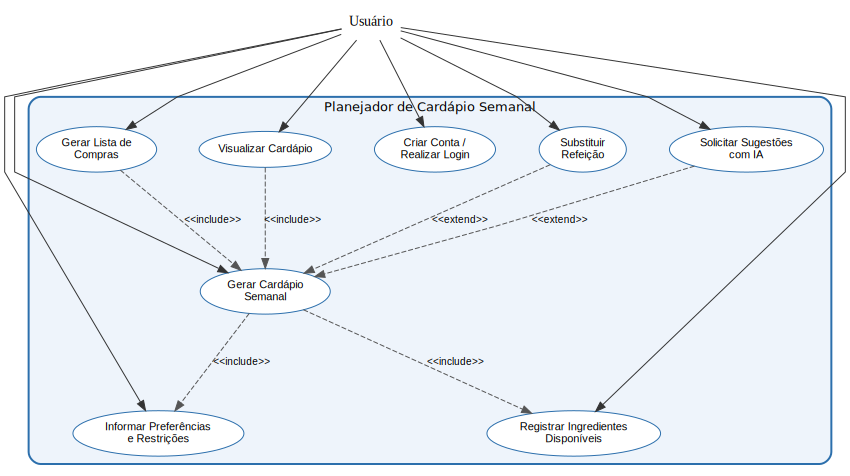

In [6]:
dot = Digraph(
    comment='Diagrama de Casos de Uso – Planejador de Cardápio Semanal',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'polyline',
        'fontname': 'Helvetica',
        'fontsize': '12',
        'fontcolor': 'black',
        'compound': 'true',
        'nodesep': '0.6',
        'ranksep': '1.2'
    }
)

# Ator
dot.node(
    'U',
    label='Usuário',
    shape='none',
)

# Fronteira do sistema (subgraph)
with dot.subgraph(name='cluster_sistema') as s:
  s.attr(
      label='Planejador de Cardápio Semanal',
      style='rounded, filled',
      fillcolor='#EEF4FB',
      color='#2C6FAC',
      penwidth='2',
      fontname='Helvetica Bold',
      fontsize='13',
  )

  uc_attrs = dict(
      shape = 'ellipse', style = 'filled',
      fillcolor = 'white', color = '#2C6FAC',
      fontname = 'Helvetica', fontsize = '11'
  )

  s.node('UC1', 'Criar Conta /\nRealizar Login', **uc_attrs)
  s.node('UC2', 'Informar Preferências\ne Restrições', **uc_attrs)
  s.node('UC3', 'Registrar Ingredientes\nDisponíveis', **uc_attrs)
  s.node('UC4', 'Gerar Cardápio\nSemanal', **uc_attrs)
  s.node('UC5', 'Substituir\nRefeição', **uc_attrs)
  s.node('UC6', 'Solicitar Sugestões\ncom IA', **uc_attrs)
  s.node('UC7', 'Gerar Lista de\nCompras', **uc_attrs)
  s.node('UC8', 'Visualizar Cardápio', **uc_attrs)

  # Relações entre UCs
  rel_attrs = dict(
      style='dashed', fontname='Helvetica',
      fontsize='10',color='#555555'
  )

  # UC4 inclui UC2 e UC3 (depende das preferências e ingredientes)
  s.edge('UC4', 'UC2', label = '\\<\\<include\\>\\>',**rel_attrs)
  s.edge('UC4', 'UC3', label = '\\<\\<include\\>\\>', **rel_attrs)

  # UC7 inclui UC4 (lista gerada a partir do cardápio)
  s.edge('UC7', 'UC4', label = '\\<\\<include\\>\\>', **rel_attrs)

  # UC8 inclui UC4 (visualização pressupõe cardápio gerado)
  s.edge('UC8', 'UC4', label = '\\<\\<include\\>\\>', **rel_attrs)

  # UC5 e UC6 estendem UC4 (ações opcionais após gerar cardápio)
  s.edge('UC5', 'UC4', label = '\\<\\<extend\\>\\>', **rel_attrs)
  s.edge('UC6', 'UC4', label = '\\<\\<extend\\>\\>', **rel_attrs)


# Ligações Ator -> UCs (apenas os iniciados diretamente pelo usuário)
for uc in ['UC1', 'UC2', 'UC3', 'UC4', 'UC5', 'UC6', 'UC7', 'UC8']:
  dot.edge('U', uc, color = '#333333')

# Renderizar imagem
dot.render('casos_de_uso_v2', format='png', cleanup=True)
dot

# Caso de Uso – Cadastro / Login

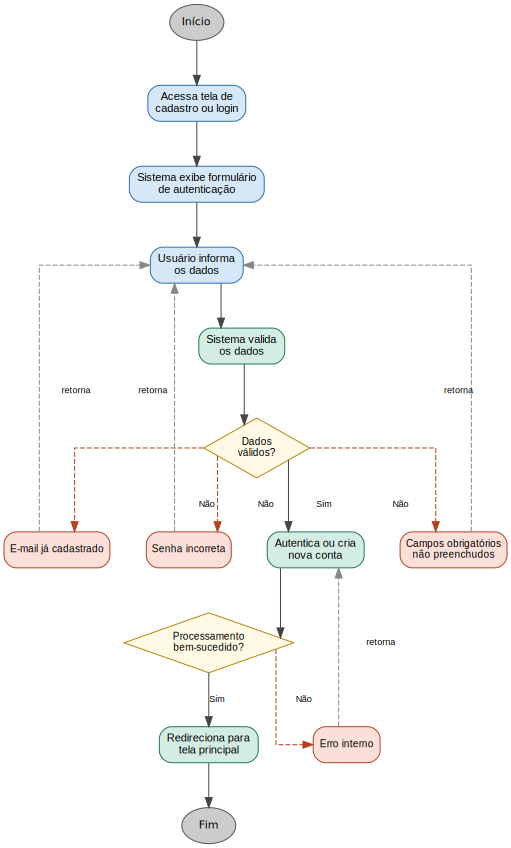

In [7]:
dot = Digraph (
    comment='Caso de Uso – Cadastro/Login',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6'
    }
)

# Estilos base
inicio_fim = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao      = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo  = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao   = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt  = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok   = dict(color='#444444', fontname='Helvetica', fontsize='9')

# Nós – fluxo principal
dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa tela de\ncadastro ou login', **acao)
dot.node('N2', 'Sistema exibe formulário\nde autenticação', **acao)
dot.node('N3', 'Usuário informa\nos dados', **acao)
dot.node('N4', 'Sistema valida\nos dados', **processo)
dot.node('D1', 'Dados\nválidos?', **decisao)
dot.node('N5', 'Autentica ou cria\nnova conta', **processo)
dot.node('D2', 'Processamento\nbem-sucedido?', **decisao)
dot.node('N6', 'Redireciona para\ntela principal', **processo)
dot.node('fim', 'Fim', **inicio_fim)

# Nós – fluxos alternativos
dot.node('FA4A', 'Campos obrigatórios\nnão preenchudos', **alternativo)
dot.node('FA4B','E-mail já cadastrado', **alternativo)
dot.node('FA4C', 'Senha incorreta', **alternativo)
dot.node('FA5A', 'Erro interno', **alternativo)

# Fluxo principal
dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'N4', **edge_ok)
dot.edge('N4', 'D1', **edge_ok)
dot.edge('D1', 'N5', label='Sim', **edge_ok)
dot.edge('N5', 'D2', **edge_ok)
dot.edge('D2', 'N6', label='Sim', **edge_ok)
dot.edge('N6', 'fim', **edge_ok)

# Fluxos alternativos
dot.edge('D1', 'FA4A', label='Não', **edge_alt)
dot.edge('D1', 'FA4B', label='Não', **edge_alt)
dot.edge('D1', 'FA4C', label='Não', **edge_alt)
dot.edge('D2', 'FA5A', label='Não', **edge_alt)

# Retornos
dot.edge('FA4A', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4B', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4C', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA5A', 'N5', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc1_cadastro_login', format='png')
dot

# Caso de Uso – Informar Preferências e Restrições  

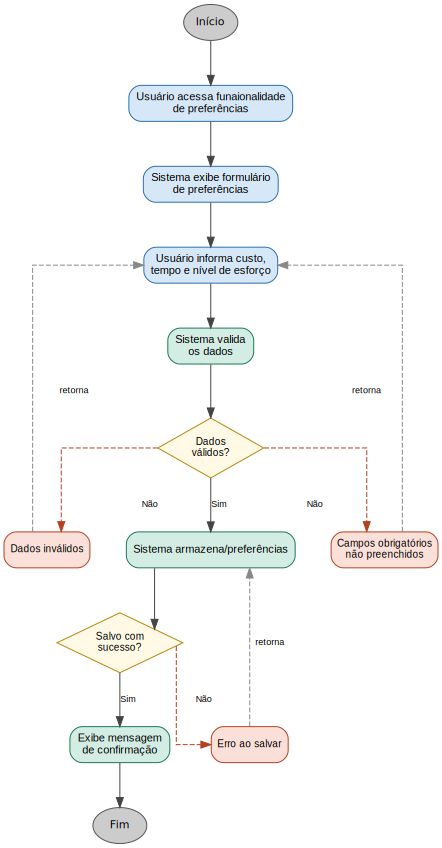

In [8]:
dot = Digraph(
    comment='Caso de Uso – Informar Preferências e Restrições',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6'
    }
)

inicio_fim = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

# Nós – fluxo principal
dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Usuário acessa funaionalidade\nde preferências', **acao)
dot.node('N2', 'Sistema exibe formulário\nde preferências', **acao)
dot.node('N3', 'Usuário informa custo,\ntempo e nível de esforço', **acao)
dot.node('N4', 'Sistema valida\nos dados', **processo)
dot.node('D1', 'Dados\nválidos?', **decisao)
dot.node('N5', 'Sistema armazena/preferências', **processo)
dot.node('D2', 'Salvo com\nsucesso?', **decisao)
dot.node('N6', 'Exibe mensagem\nde confirmação', **processo)
dot.node('fim', 'Fim', **inicio_fim)

# Nós – fluxos alternativos
dot.node('FA4A', 'Campos obrigatórios\nnão preenchidos', **alternativo)
dot.node('FA4B', 'Dados inválidos', **alternativo)
dot.node('FA5A', 'Erro ao salvar', **alternativo)

# Fluxo principal
dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'N4', **edge_ok)
dot.edge('N4', 'D1', **edge_ok)
dot.edge('D1', 'N5', label='Sim', **edge_ok)
dot.edge('N5', 'D2', **edge_ok)
dot.edge('D2', 'N6', label='Sim', **edge_ok)
dot.edge('N6', 'fim', **edge_ok)

# Fluxos alternativos
dot.edge('D1', 'FA4A', label='Não', **edge_alt)
dot.edge('D1', 'FA4B', label='Não', **edge_alt)
dot.edge('D2', 'FA5A', label='Não', **edge_alt)

# Retornos
dot.edge('FA4A', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4B', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA5A', 'N5', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc2_preferencias_restricoes', format='png')
dot

# Caso de Uso – Registrar Ingredientes Disponíveis  

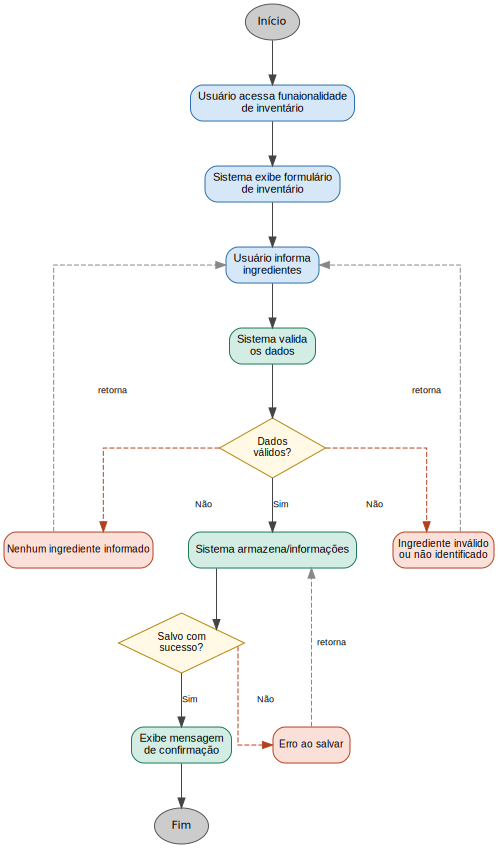

In [9]:
dot = Digraph(
    comment='Caso de Uso – Registrar Ingredientes Disponíveis',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6'
    }
)

inicio_fim = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

# Nós – fluxo principal
dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Usuário acessa funaionalidade\nde inventário', **acao)
dot.node('N2', 'Sistema exibe formulário\nde inventário', **acao)
dot.node('N3', 'Usuário informa\ningredientes', **acao)
dot.node('N4', 'Sistema valida\nos dados', **processo)
dot.node('D1', 'Dados\nválidos?', **decisao)
dot.node('N5', 'Sistema armazena/informações', **processo)
dot.node('D2', 'Salvo com\nsucesso?', **decisao)
dot.node('N6', 'Exibe mensagem\nde confirmação', **processo)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA4A', 'Ingrediente inválido\nou não identificado', **alternativo)
dot.node('FA4B', 'Nenhum ingrediente informado', **alternativo)
dot.node('FA5A', 'Erro ao salvar', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'N4', **edge_ok)
dot.edge('N4', 'D1', **edge_ok)
dot.edge('D1', 'N5', label='Sim', **edge_ok)
dot.edge('N5', 'D2', **edge_ok)
dot.edge('D2', 'N6', label='Sim', **edge_ok)
dot.edge('N6', 'fim', **edge_ok)

dot.edge('D1', 'FA4A', label='Não', **edge_alt)
dot.edge('D1', 'FA4B', label='Não', **edge_alt)
dot.edge('D2', 'FA5A', label='Não', **edge_alt)

dot.edge('FA4A', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4B', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA5A', 'N5', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc3_registrar_ingredientes', format='png')
dot

# Caso de Uso – Gerar Cardápio Semanal   

In [10]:
from graphviz import Digraph

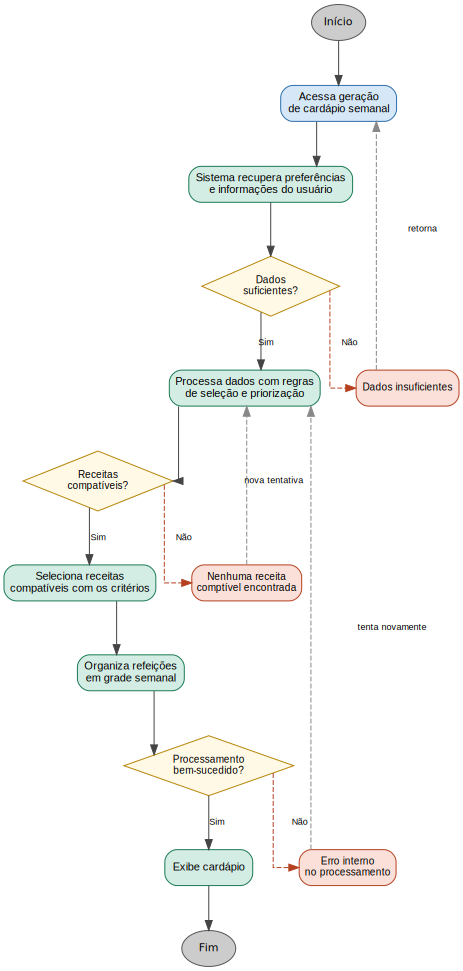

In [11]:
dot = Digraph(
    comment='UC4 – Gerar Cardápio Semanal',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6',
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa geração\nde cardápio semanal', **acao)
dot.node('N2', 'Sistema recupera preferências\ne informações do usuário', **processo)
dot.node('D0', 'Dados\nsuficientes?', **decisao)
dot.node('N3', 'Processa dados com regras\nde seleção e priorização', **processo)
dot.node('D1', 'Receitas\ncompatíveis?', **decisao)
dot.node('N4', 'Seleciona receitas\ncompatíveis com os critérios', **processo)
dot.node('N5', 'Organiza refeições\nem grade semanal', **processo)
dot.node('D2', 'Processamento\nbem-sucedido?', **decisao)
dot.node('N6', 'Exibe cardápio', **processo)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA3A', 'Dados insuficientes', **alternativo)
dot.node('FA4A', 'Nenhuma receita\ncomptível encontrada', **alternativo)
dot.node('FA5A', 'Erro interno\nno processamento', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'D0', **edge_ok)
dot.edge('D0', 'N3', label='Sim', **edge_ok)
dot.edge('N3', 'D1', **edge_ok)
dot.edge('D1', 'N4', label='Sim', **edge_ok)
dot.edge('N4', 'N5', **edge_ok)
dot.edge('N5', 'D2', **edge_ok)
dot.edge('D2', 'N6', label='Sim', **edge_ok)
dot.edge('N6', 'fim', **edge_ok)

dot.edge('D0', 'FA3A', label='Não', **edge_alt)
dot.edge('D1', 'FA4A', label='Não', **edge_alt)
dot.edge('D2', 'FA5A', label='Não', **edge_alt)


dot.edge('FA3A', 'N1', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4A', 'N3', label='nova tentativa', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA5A', 'N3', label='tenta novamente', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc4_gerar_cardapio_semanal', format='png', cleanup=True)
dot

# Caso de Uso – Substituir Sugestões de Refeições

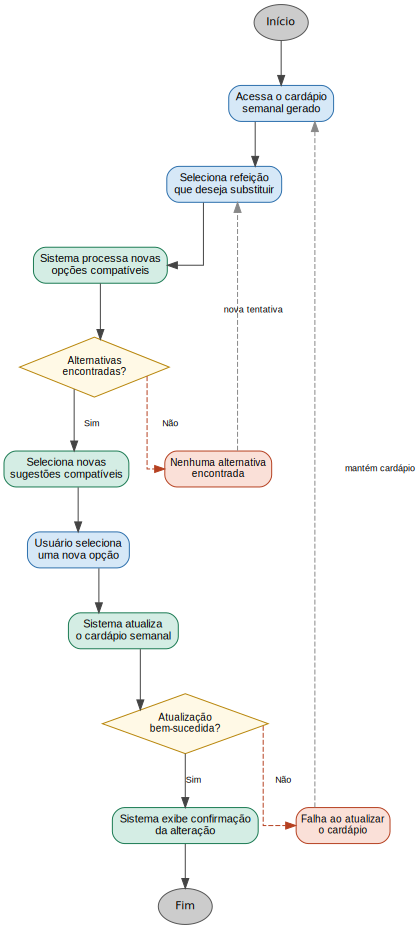

In [12]:
dot = Digraph(
    comment='UC5 – Substituir Sugestões de Refeições',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6',
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa o cardápio\nsemanal gerado', **acao)
dot.node('N2', 'Seleciona refeição\nque deseja substituir', **acao)
dot.node('N3', 'Sistema processa novas\nopções compatíveis', **processo)
dot.node('D1', 'Alternativas\nencontradas?', **decisao)
dot.node('N4', 'Seleciona novas\nsugestões compatíveis', **processo)
dot.node('N5', 'Usuário seleciona\numa nova opção', **acao)
dot.node('N6', 'Sistema atualiza\no cardápio semanal', **processo)
dot.node('D2', 'Atualização\nbem-sucedida?', **decisao)
dot.node('N7', 'Sistema exibe confirmação\nda alteração', **processo)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA3A', 'Nenhuma alternativa\nencontrada', **alternativo)
dot.node('FA6A', 'Falha ao atualizar\no cardápio', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'D1', **edge_ok)
dot.edge('D1', 'N4', label='Sim', **edge_ok)
dot.edge('N4', 'N5', **edge_ok)
dot.edge('N5', 'N6', **edge_ok)
dot.edge('N6', 'D2', **edge_ok)
dot.edge('D2', 'N7', label='Sim', **edge_ok)
dot.edge('N7', 'fim', **edge_ok)

dot.edge('D1', 'FA3A', label='Não', **edge_alt)
dot.edge('D2', 'FA6A', label='Não', **edge_alt)

dot.edge('FA3A', 'N2', label='nova tentativa', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA6A', 'N1', label='mantém cardápio', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc5_substituir_refeicao', format='png', cleanup=True)
dot

# Caso de Uso – Solicitar Sugestões Adicionais Utilizando IA   

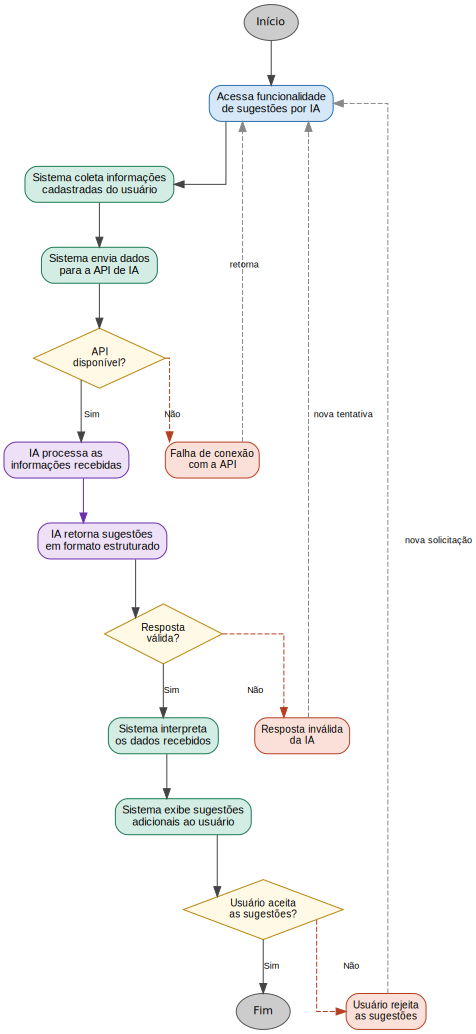

In [13]:
dot = Digraph(
    comment='UC6 – Solicitar Sugestões com IA',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6',
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
ia          = dict(shape='box', style='filled,rounded', fillcolor='#EDE0F7', color='#6A2FAC', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')
edge_ia     = dict(color='#6A2FAC', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa funcionalidade\nde sugestões por IA', **acao)
dot.node('N2', 'Sistema coleta informações\ncadastradas do usuário', **processo)
dot.node('N3', 'Sistema envia dados\npara a API de IA', **processo)
dot.node('D1', 'API\ndisponível?', **decisao)
dot.node('N4', 'IA processa as\ninformações recebidas', **ia)
dot.node('N5', 'IA retorna sugestões\nem formato estruturado', **ia)
dot.node('D2', 'Resposta\nválida?', **decisao)
dot.node('N6', 'Sistema interpreta\nos dados recebidos', **processo)
dot.node('N7', 'Sistema exibe sugestões\nadicionais ao usuário', **processo)
dot.node('D3', 'Usuário aceita\nas sugestões?', **decisao)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA3A', 'Falha de conexão\ncom a API', **alternativo)
dot.node('FA5A', 'Resposta inválida\nda IA', **alternativo)
dot.node('FA7A', 'Usuário rejeita\nas sugestões', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'D1', **edge_ok)
dot.edge('D1', 'N4', label='Sim', **edge_ok)
dot.edge('N4', 'N5', **edge_ia)
dot.edge('N5', 'D2', **edge_ok)
dot.edge('D2', 'N6', label='Sim', **edge_ok)
dot.edge('N6', 'N7', **edge_ok)
dot.edge('N7', 'D3', **edge_ok)
dot.edge('D3', 'fim', label='Sim', **edge_ok)

dot.edge('D1', 'FA3A', label='Não', **edge_alt)
dot.edge('D2', 'FA5A', label='Não', **edge_alt)
dot.edge('D3', 'FA7A', label='Não', **edge_alt)

dot.edge('FA3A', 'N1', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA5A', 'N1', label='nova tentativa', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA7A', 'N1', label='nova solicitação', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc6_sugestoes_ia', format='png', cleanup=True)
dot

# Caso de Uso – Gerar Lista de Compras Automática    

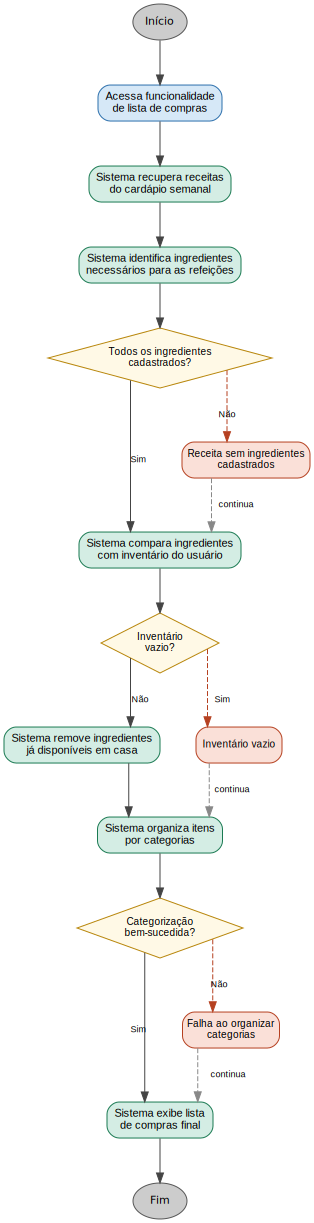

In [14]:
dot = Digraph(
    comment='UC7 – Gerar Lista de Compras Automática',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6',
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa funcionalidade\nde lista de compras', **acao)
dot.node('N2', 'Sistema recupera receitas\ndo cardápio semanal', **processo)
dot.node('N3', 'Sistema identifica ingredientes\nnecessários para as refeições', **processo)
dot.node('D1', 'Todos os ingredientes\ncadastrados?', **decisao)
dot.node('N4', 'Sistema compara ingredientes\ncom inventário do usuário', **processo)
dot.node('D2', 'Inventário\nvazio?', **decisao)
dot.node('N5', 'Sistema remove ingredientes\njá disponíveis em casa', **processo)
dot.node('N6', 'Sistema organiza itens\npor categorias', **processo)
dot.node('D3', 'Categorização\nbem-sucedida?', **decisao)
dot.node('N7', 'Sistema exibe lista\nde compras final', **processo)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA3A', 'Receita sem ingredientes\ncadastrados', **alternativo)
dot.node('FA4A', 'Inventário vazio', **alternativo)
dot.node('FA6A', 'Falha ao organizar\ncategorias', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1',   'N2', **edge_ok)
dot.edge('N2',   'N3', **edge_ok)
dot.edge('N3',   'D1', **edge_ok)
dot.edge('D1',   'N4', label='Sim', **edge_ok)
dot.edge('N4',   'D2', **edge_ok)
dot.edge('D2',   'N5', label='Não', **edge_ok)
dot.edge('N5',   'N6', **edge_ok)
dot.edge('N6',   'D3', **edge_ok)
dot.edge('D3',   'N7', label='Sim', **edge_ok)
dot.edge('N7',   'fim', **edge_ok)

dot.edge('D1', 'FA3A', label='Não', **edge_alt)
dot.edge('D2', 'FA4A', label='Sim', **edge_alt)
dot.edge('D3', 'FA6A', label='Não', **edge_alt)

dot.edge('FA3A', 'N4', label='continua', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4A', 'N6', label='continua', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA6A', 'N7', label='continua', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc7_lista_de_compras', format='png', cleanup=True)
dot

# Caso de Uso – Visualizar Cardápio e Ingredientes Utilizados    

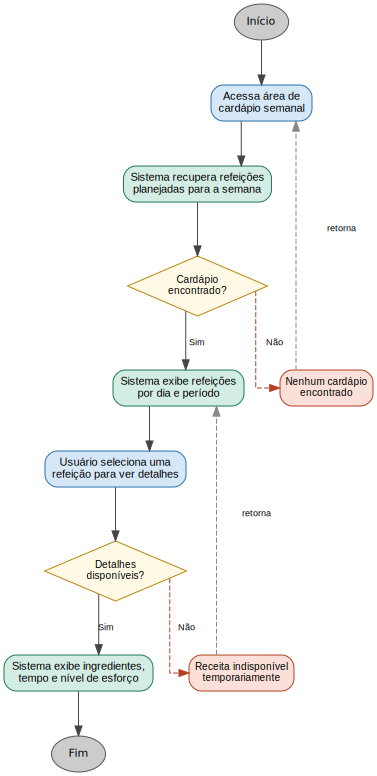

In [15]:
dot = Digraph(
    comment='UC8 – Visualizar Cardápio e Ingredientes Utilizados',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6',
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
alternativo = dict(shape='box', style='filled,rounded', fillcolor='#FAE0D8', color='#B54020', fontname='Helvetica', fontsize='10')
edge_alt    = dict(style='dashed', color='#B54020', fontname='Helvetica', fontsize='9')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Acessa área de\ncardápio semanal', **acao)
dot.node('N2', 'Sistema recupera refeições\nplanejadas para a semana', **processo)
dot.node('D1', 'Cardápio\nencontrado?', **decisao)
dot.node('N3', 'Sistema exibe refeições\npor dia e período', **processo)
dot.node('N4', 'Usuário seleciona uma\nrefeição para ver detalhes', **acao)
dot.node('D2', 'Detalhes\ndisponíveis?', **decisao)
dot.node('N5', 'Sistema exibe ingredientes,\ntempo e nível de esforço', **processo)
dot.node('fim', 'Fim', **inicio_fim)

dot.node('FA2A', 'Nenhum cardápio\nencontrado', **alternativo)
dot.node('FA4A', 'Receita indisponível\ntemporariamente', **alternativo)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1',   'N2', **edge_ok)
dot.edge('N2',   'D1', **edge_ok)
dot.edge('D1',   'N3', label='Sim', **edge_ok)
dot.edge('N3',   'N4', **edge_ok)
dot.edge('N4',   'D2', **edge_ok)
dot.edge('D2',   'N5', label='Sim', **edge_ok)
dot.edge('N5',   'fim', **edge_ok)

dot.edge('D1', 'FA2A', label='Não', **edge_alt)
dot.edge('D2', 'FA4A', label='Não', **edge_alt)

dot.edge('FA2A', 'N1', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')
dot.edge('FA4A', 'N3', label='retorna', style='dashed', color='#888888', fontsize='9', fontname='Helvetica')

dot.render('uc8_visualizar_cardapio', format='png', cleanup=True)
dot

# Diagrama de atividades/Fluxograma Geral para o 3.1

In [16]:
from graphviz import Digraph

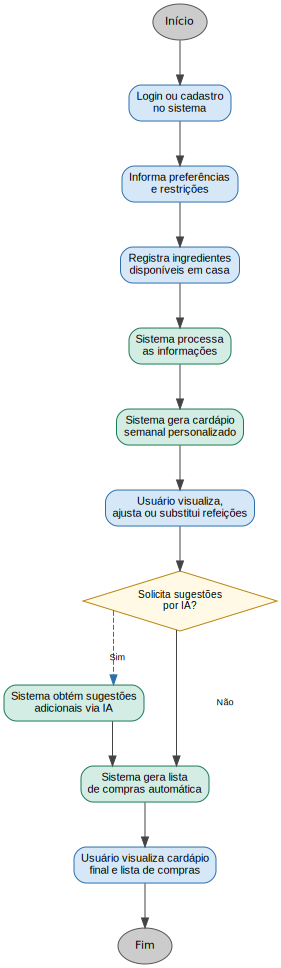

In [17]:
dot = Digraph(
    comment = 'Fluxo Principal do Usuário',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.5',
        'ranksep': '0.6'
    }
)

inicio_fim  = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
acao        = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
processo    = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica', fontsize='11')
decisao     = dict(shape='diamond', style='filled', fillcolor='#FFF9E6', color='#B8860B', fontname='Helvetica', fontsize='10')
edge_ok     = dict(color='#444444', fontname='Helvetica', fontsize='9')
edge_op     = dict(color='#2C6FAC', style='dashed', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio_fim)
dot.node('N1', 'Login ou cadastro\nno sistema', **acao)
dot.node('N2', 'Informa preferências\ne restrições', **acao)
dot.node('N3', 'Registra ingredientes\ndisponíveis em casa', **acao)
dot.node('N4', 'Sistema processa\nas informações', **processo)
dot.node('N5', 'Sistema gera cardápio\nsemanal personalizado', **processo)
dot.node('N6', 'Usuário visualiza,\najusta ou substitui refeições', **acao)
dot.node('D1', 'Solicita sugestões\npor IA?', **decisao)
dot.node('N7', 'Sistema obtém sugestões\nadicionais via IA', **processo)
dot.node('N8', 'Sistema gera lista\nde compras automática', **processo)
dot.node('N9', 'Usuário visualiza cardápio\nfinal e lista de compras', **acao)
dot.node('fim', 'Fim', **inicio_fim)

dot.edge('inicio', 'N1', **edge_ok)
dot.edge('N1', 'N2', **edge_ok)
dot.edge('N2', 'N3', **edge_ok)
dot.edge('N3', 'N4', **edge_ok)
dot.edge('N4', 'N5', **edge_ok)
dot.edge('N5', 'N6', **edge_ok)
dot.edge('N6', 'D1', **edge_ok)
dot.edge('D1', 'N7', label='Sim', **edge_op)
dot.edge('D1', 'N8', label='Não', **edge_ok)
dot.edge('N7', 'N8', **edge_ok)
dot.edge('N8', 'N9', **edge_ok)
dot.edge('N9', 'fim', **edge_ok)

dot.render('fluxo_principal_usuario', format='png')
dot

# Diagrama de fluxo de navegação

In [18]:
from graphviz import Digraph

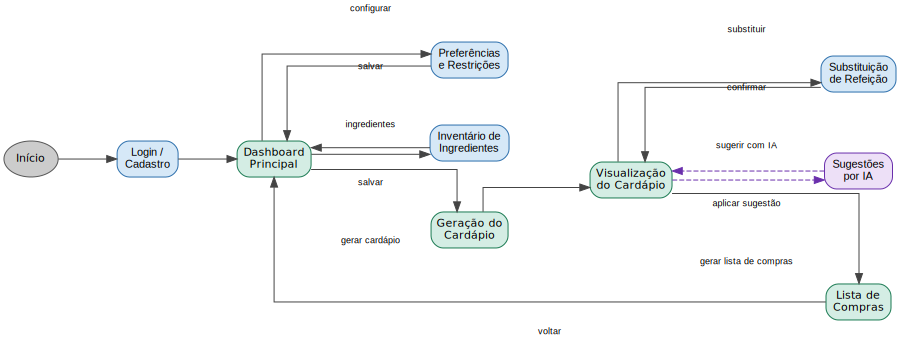

In [19]:
dot = Digraph(
    comment = 'Fluxo de Navegação – Planejador de Cardápio Semanal',
    graph_attr={
        'rankdir': 'LR',
        'splines': 'ortho',
        'fontname': 'Helvetica',
        'nodesep': '0.6',
        'ranksep': '0.8'
    }
)

tela     = dict(shape='box', style='filled,rounded', fillcolor='#D6E8F7', color='#2C6FAC', fontname='Helvetica', fontsize='11')
destaque = dict(shape='box', style='filled,rounded', fillcolor='#D4EDE4', color='#1A7A52', fontname='Helvetica Bold', fontsize='11')
opcional = dict(shape='box', style='filled,rounded', fillcolor='#EDE0F7', color='#6A2FAC', fontname='Helvetica', fontsize='11')
inicio   = dict(shape='ellipse', style='filled', fillcolor='#CCCCCC', color='#555555', fontname='Helvetica Bold', fontsize='11')
edge_ok  = dict(color='#444444', fontname='Helvetica', fontsize='9')
edge_op  = dict(color='#6A2FAC', style='dashed', fontname='Helvetica', fontsize='9')

dot.node('inicio', 'Início', **inicio)
dot.node('T1', 'Login /\nCadastro', **tela)
dot.node('T2', 'Dashboard\nPrincipal', **destaque)
dot.node('T3', 'Preferências\ne Restrições', **tela)
dot.node('T4', 'Inventário de\nIngredientes', **tela)
dot.node('T5', 'Geração do\nCardápio', **destaque)
dot.node('T6', 'Visualização\ndo Cardápio', **destaque)
dot.node('T7', 'Substituição\nde Refeição', **tela)
dot.node('T8', 'Sugestões\npor IA', **opcional)
dot.node('T9', 'Lista de\nCompras', **destaque)

dot.edge('inicio', 'T1', **edge_ok)
dot.edge('T1', 'T2', **edge_ok)
dot.edge('T2', 'T3', label='configurar', **edge_ok)
dot.edge('T2', 'T4', label='ingredientes', **edge_ok)
dot.edge('T2', 'T5', label='gerar cardápio', **edge_ok)
dot.edge('T3', 'T2', label='salvar', **edge_ok)
dot.edge('T4', 'T2', label='salvar', **edge_ok)
dot.edge('T5', 'T6', **edge_ok)
dot.edge('T6', 'T7', label='substituir', **edge_ok)
dot.edge('T6', 'T8', label='sugerir com IA', **edge_op)
dot.edge('T6', 'T9', label='gerar lista de compras', **edge_ok)
dot.edge('T7', 'T6', label='confirmar', **edge_ok)
dot.edge('T8', 'T6', label='aplicar sugestão', **edge_op)
dot.edge('T9', 'T2', label='voltar', **edge_ok)

dot.render('fluxo_navegacao', format='png')
dot

# Diagramas C4

## Nível 1 – Contexto

In [20]:
from graphviz import Digraph

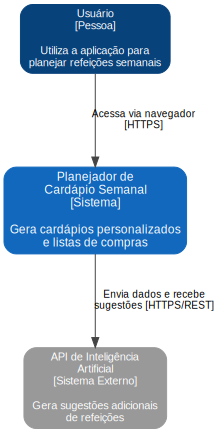

In [21]:
dot = Digraph(
    comment = 'C4 Nível 1 – Diagrama de Contexto',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Arial',
        'nodesep': '0.8',
        'ranksep': '1.0',
        'bgcolor': 'white',
    }
)

pessoa   = dict(shape='box', style='filled,rounded', fillcolor='#08427B', fontcolor='white', color='#08427B', fontname='Arial', fontsize='11')
sistema  = dict(shape='box', style='filled,rounded', fillcolor='#1168BD', fontcolor='white', color='#1168BD', fontname='Arial', fontsize='12')
externo  = dict(shape='box', style='filled,rounded', fillcolor='#999999', fontcolor='white', color='#999999', fontname='Arial', fontsize='11')
edge_ok  = dict(color='#444444', fontname='Arial', fontsize='10')

dot.node('U', 'Usuário\n[Pessoa]\n\nUtiliza a aplicação para\nplanejar refeições semanais', **pessoa)
dot.node('SYS', 'Planejador de\nCardápio Semanal\n[Sistema]\n\nGera cardápios personalizados\ne listas de compras', **sistema)
dot.node('AI', 'API de Inteligência\nArtificial\n[Sistema Externo]\n\nGera sugestões adicionais\nde refeições', **externo)

dot.edge('U', 'SYS', label='Acessa via navegador\n[HTTPS]', **edge_ok)
dot.edge('SYS', 'AI', label='Envia dados e recebe\nsugestões [HTTPS/REST]', **edge_ok)

dot.render('c4_nivel1_contexto', format='png', cleanup=True)
dot

## Nível 2 – Containers

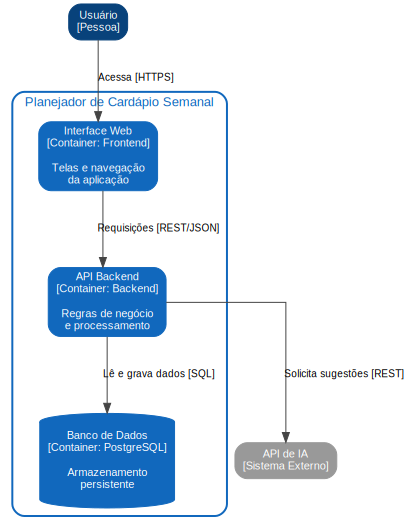

In [22]:
dot = Digraph(
    comment = 'C4 Nível 2 – Diagrama de Containers',
    graph_attr={
        'rankdir': 'TB',
        'splines': 'ortho',
        'fontname': 'Arial',
        'nodesep': '0.7',
        'ranksep': '0.9',
        'compound': 'true',
    }
)

pessoa  = dict(shape='box', style='filled,rounded', fillcolor='#08427B', fontcolor='white', color='#08427B', fontname='Arial', fontsize='11')
externo = dict(shape='box', style='filled,rounded', fillcolor='#999999', fontcolor='white', color='#999999', fontname='Arial', fontsize='11')
edge_ok = dict(color='#444444', fontname='Arial', fontsize='10')

dot.node('U', 'Usuário\n[Pessoa]', **pessoa)
dot.node('AI', 'API de IA\n[Sistema Externo]', **externo)

with dot.subgraph(name='cluster_sistema') as s:
  s.attr(
      label='Planejador de Cardápio Semanal',
      style='rounded',
      color='#1168BD',
      fontcolor='#1168BD',
      fontname='Arial',
      fontsize='13',
      penwidth='2',
  )

  cont = dict(shape='box', style='filled,rounded', fillcolor='#1168BD', fontcolor='white', color='#1168BD', fontname='Arial', fontsize='11')
  db   = dict(shape='cylinder', style='filled', fillcolor='#1168BD', fontcolor='white', color='#1168BD', fontname='Arial', fontsize='11')

  s.node('FE', 'Interface Web\n[Container: Frontend]\n\nTelas e navegação\nda aplicação', **cont)
  s.node('BE', 'API Backend\n[Container: Backend]\n\nRegras de negócio\ne processamento', **cont)
  s.node('DB', 'Banco de Dados\n[Container: PostgreSQL]\n\nArmazenamento\npersistente', **db)

dot.edge('U', 'FE', label='Acessa [HTTPS]', **edge_ok)
dot.edge('FE', 'BE', label='Requisições [REST/JSON]', **edge_ok)
dot.edge('BE', 'DB', label='Lê e grava dados [SQL]', **edge_ok)
dot.edge('BE', 'AI', label='Solicita sugestões [REST]', **edge_ok)

dot.render('c4_nivel2_containers', format='png', cleanup=True)
dot

##Nível 3 – Componentes (foco no Backend)

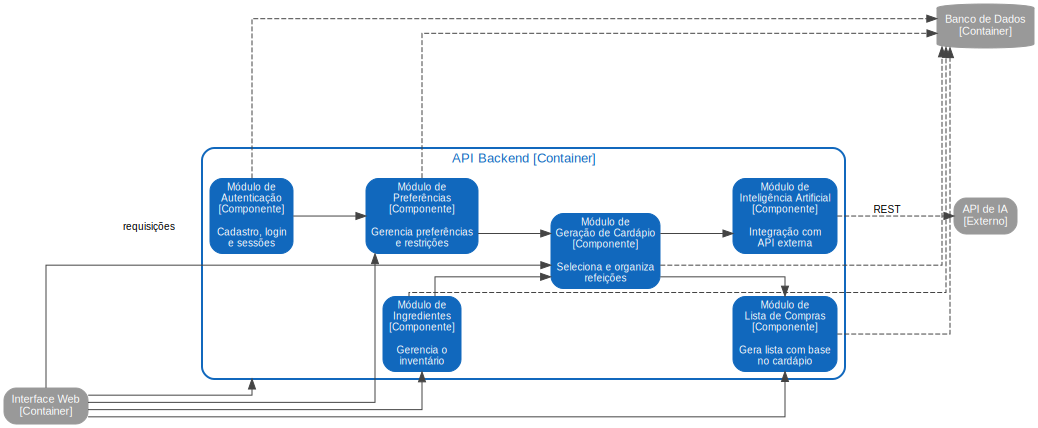

In [23]:
dot = Digraph(
    comment='C4 Nível 3 – Diagrama de Componentes (Backend)',
    graph_attr={
        'rankdir': 'LR',
        'splines': 'ortho',
        'fontname': 'Arial',
        'nodesep': '0.6',
        'ranksep': '1.0',
        'compound': 'true',
    }
)

externo = dict(shape='box', style='filled,rounded', fillcolor='#999999', fontcolor='white', color='#999999', fontname='Arial', fontsize='11')
edge_ok = dict(color='#444444', fontname='Arial', fontsize='10')
edge_db = dict(color='#444444', fontname='Arial', fontsize='10', style='dashed')


dot.node('FE', 'Interface Web\n[Container]', **externo)
dot.node('DB', 'Banco de Dados\n[Container]', shape='cylinder', style='filled', fillcolor='#999999', fontcolor='white', color='#999999', fontname='Arial', fontsize='11')
dot.node('BE', 'API de IA\n[Externo]', **externo)

with dot.subgraph(name='cluster_backend') as s:
  s.attr(
      label='API Backend [Container]',
      style='rounded',
      color='#1168BD',
      fontcolor='#1168BD',
      fontname='Arial',
      fontsize='13',
      penwidth='2',
  )

  comp = dict(shape='box', style='filled,rounded', fillcolor='#1168BD', fontcolor='white', color='#1168BD', fontname='Arial', fontsize='10')

  s.node('AUTH', 'Módulo de\nAutenticação\n[Componente]\n\nCadastro, login\ne sessões', **comp)
  s.node('PREF', 'Módulo de\nPreferências\n[Componente]\n\nGerencia preferências\ne restrições', **comp)
  s.node('INGR', 'Módulo de\nIngredientes\n[Componente]\n\nGerencia o\ninventário', **comp)
  s.node('CARD', 'Módulo de\nGeração de Cardápio\n[Componente]\n\nSeleciona e organiza\nrefeições', **comp)
  s.node('LISTA', 'Módulo de\nLista de Compras\n[Componente]\n\nGera lista com base\nno cardápio', **comp)
  s.node('AIMOD', 'Módulo de\nInteligência Artificial\n[Componente]\n\nIntegração com\nAPI externa', **comp)

  s.edge('AUTH', 'PREF', **edge_ok)
  s.edge('PREF', 'CARD', **edge_ok)
  s.edge('INGR', 'CARD', **edge_ok)
  s.edge('CARD', 'LISTA', **edge_ok)
  s.edge('CARD', 'AIMOD', **edge_ok)

dot.edge('FE', 'AUTH', label='requisições', lhead='cluster_backend', **edge_ok)
dot.edge('FE', 'PREF', **edge_ok)
dot.edge('FE', 'INGR', **edge_ok)
dot.edge('FE', 'CARD', **edge_ok)
dot.edge('FE', 'LISTA', **edge_ok)

dot.edge('AUTH', 'DB', **edge_db)
dot.edge('PREF', 'DB', **edge_db)
dot.edge('INGR', 'DB', **edge_db)
dot.edge('CARD', 'DB', **edge_db)
dot.edge('LISTA', 'DB', **edge_db)
dot.edge('AIMOD', 'BE', label='REST', **edge_db)

dot.render('c4_nivel3_componentes', format='png', cleanup=True)
dot

# Diagrama Entidade-Relacionamento (DER)

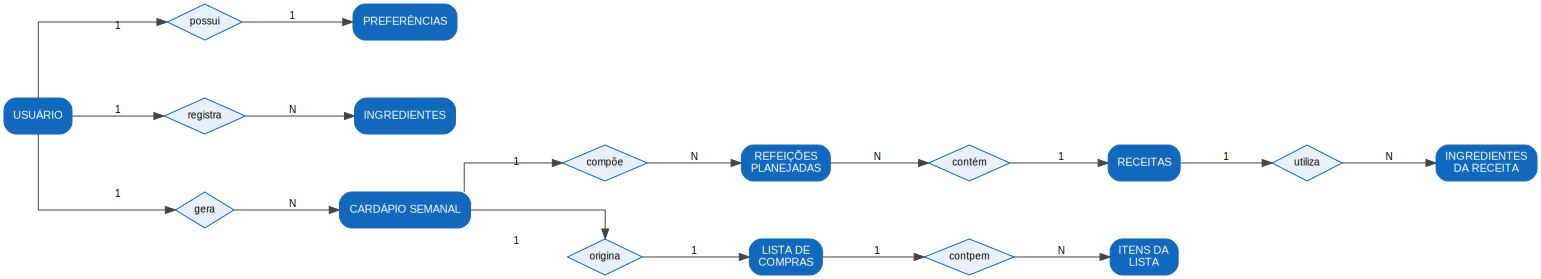

In [24]:
dot = Digraph(
    comment='DER – Planejador de Cardápio Semanal',
    graph_attr={
        'rankdir': 'LR',
        'splines': 'ortho',
        'fontname': 'Arial',
        'nodesep': '0.8',
        'ranksep': '1.2',
    }
)

entidade = dict(shape='box', style='filled,rounded', fillcolor='#1168BD', fontcolor='white', color='#1168BD', fontname='Arial', fontsize='11')
relacao  = dict(shape='diamond', style='filled', fillcolor='#E8F0FB', color='#1168BD', fontname='Arial', fontsize='10')
edge_ok  = dict(color='#444444', fontname='Arial', fontsize='10')

# Entidades
dot.node('U', 'USUÁRIO', **entidade)
dot.node('P', 'PREFERÊNCIAS', **entidade)
dot.node('I', 'INGREDIENTES', **entidade)
dot.node('R', 'RECEITAS', **entidade)
dot.node('C', 'CARDÁPIO SEMANAL', **entidade)
dot.node('RF', 'REFEIÇÕES\nPLANEJADAS', **entidade)
dot.node('L', 'LISTA DE\nCOMPRAS', **entidade)
dot.node('LI', 'ITENS DA\nLISTA', **entidade)
dot.node('RI', 'INGREDIENTES\nDA RECEITA', **entidade)

# Relacionamentos
dot.node('r1', 'possui', **relacao)
dot.node('r2', 'registra', **relacao)
dot.node('r3', 'gera', **relacao)
dot.node('r4', 'compõe', **relacao)
dot.node('r5', 'contém', **relacao)
dot.node('r6', 'origina', **relacao)
dot.node('r7', 'contpem', **relacao)
dot.node('r8', 'utiliza', **relacao)

# Usuário → Preferências (1:1)
dot.edge('U',  'r1', label='1', **edge_ok)
dot.edge('r1', 'P',  label='1', **edge_ok)

# Usuário → Ingredientes (1:N)
dot.edge('U',  'r2', label='1', **edge_ok)
dot.edge('r2', 'I',  label='N', **edge_ok)

# Usuário → Cardápio (1:N)
dot.edge('U',  'r3', label='1', **edge_ok)
dot.edge('r3', 'C',  label='N', **edge_ok)

# Cardápio → Refeições Planejadas (1:N)
dot.edge('C',  'r4', label='1', **edge_ok)
dot.edge('r4', 'RF', label='N', **edge_ok)

# Refeições Planejadas → Receitas (N:1)
dot.edge('RF', 'r5', label='N', **edge_ok)
dot.edge('r5', 'R',  label='1', **edge_ok)

# Cardápio → Lista de Compras (1:1)
dot.edge('C',  'r6', label='1', **edge_ok)
dot.edge('r6', 'L',  label='1', **edge_ok)

# Lista de Compras → Itens da Lista (1:N)
dot.edge('L',  'r7', label='1', **edge_ok)
dot.edge('r7', 'LI', label='N', **edge_ok)

# Receitas → Ingredientes da Receita (1:N)
dot.edge('R',  'r8', label='1', **edge_ok)
dot.edge('r8', 'RI', label='N', **edge_ok)

dot.render('der_planejador_cardapio', format='png', cleanup=True)
dot

# Esquema Relacional

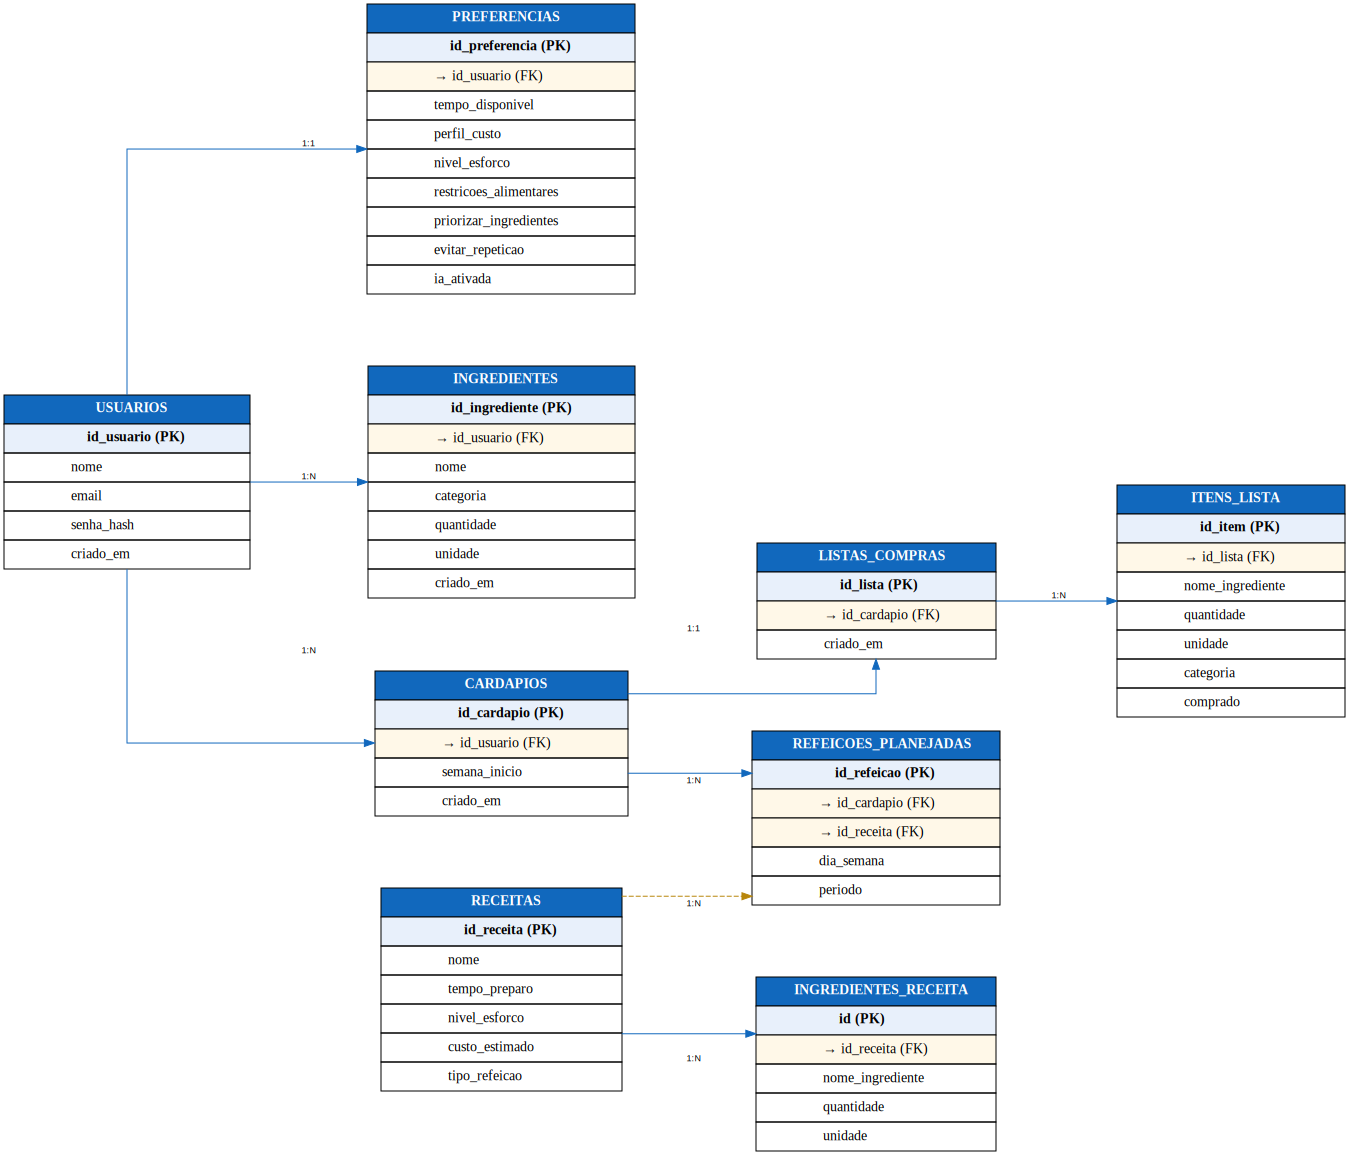

In [25]:
dot = Digraph(
    comment='Esquema Relacional – Planejador de Cardápio Semanal',
    graph_attr={
        'rankdir': 'LR',
        'splines': 'ortho',
        'fontname': 'Arial',
        'nodesep': '1.0',
        'ranksep': '1.4',
    }
)

def tabela(dot, nome, node_id, atributos):
    """
    atributos: lista de strings. Prefixe com '🔑 ' para PK e '→ ' para FK.
    """

    linhas = f'<\n<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="6">\n'

    linhas += f'''
    <TR>
      <TD BGCOLOR="#1168BD">
        <FONT COLOR="white"><B>{nome}</B></FONT>
      </TD>
    </TR>
    '''

    for atr in atributos:

        if atr.startswith('🔑'):
            linhas += f'''
            <TR>
              <TD ALIGN="LEFT" BGCOLOR="#E8F0FB">
                <B>{atr}</B>
              </TD>
            </TR>
            '''

        elif atr.startswith('→'):
            linhas += f'''
            <TR>
              <TD ALIGN="LEFT" BGCOLOR="#FFF8E8">
                {atr}
              </TD>
            </TR>
            '''

        else:
            linhas += f'''
            <TR>
              <TD ALIGN="LEFT">
                {atr}
              </TD>
            </TR>
            '''

    linhas += '</TABLE>>'

    dot.node(node_id, label=linhas, shape='none', margin='0')



# TABELAS

tabela(dot, 'USUARIOS', 'U', [
    '🔑 id_usuario (PK)',
    'nome',
    'email',
    'senha_hash',
    'criado_em',
])

tabela(dot, 'PREFERENCIAS', 'P', [
    '🔑 id_preferencia (PK)',
    '→ id_usuario (FK)',
    'tempo_disponivel',
    'perfil_custo',
    'nivel_esforco',
    'restricoes_alimentares',
    'priorizar_ingredientes',
    'evitar_repeticao',
    'ia_ativada',
])

tabela(dot, 'INGREDIENTES', 'I', [
    '🔑 id_ingrediente (PK)',
    '→ id_usuario (FK)',
    'nome',
    'categoria',
    'quantidade',
    'unidade',
    'criado_em',
])

tabela(dot, 'RECEITAS', 'R', [
    '🔑 id_receita (PK)',
    'nome',
    'tempo_preparo',
    'nivel_esforco',
    'custo_estimado',
    'tipo_refeicao',
])

tabela(dot, 'INGREDIENTES_RECEITA', 'IR', [
    '🔑 id (PK)',
    '→ id_receita (FK)',
    'nome_ingrediente',
    'quantidade',
    'unidade',
])

tabela(dot, 'CARDAPIOS', 'C', [
    '🔑 id_cardapio (PK)',
    '→ id_usuario (FK)',
    'semana_inicio',
    'criado_em',
])

tabela(dot, 'REFEICOES_PLANEJADAS', 'RF', [
    '🔑 id_refeicao (PK)',
    '→ id_cardapio (FK)',
    '→ id_receita (FK)',
    'dia_semana',
    'periodo',
])

tabela(dot, 'LISTAS_COMPRAS', 'L', [
    '🔑 id_lista (PK)',
    '→ id_cardapio (FK)',
    'criado_em',
])

tabela(dot, 'ITENS_LISTA', 'LI', [
    '🔑 id_item (PK)',
    '→ id_lista (FK)',
    'nome_ingrediente',
    'quantidade',
    'unidade',
    'categoria',
    'comprado',
])



# RELACIONAMENTOS

edge_pk = dict(
    color='#1168BD',
    fontname='Arial',
    fontsize='9'
)


edge_fk = dict(
    color='#B8860B',
    fontname='Arial',
    fontsize='9',
    style='dashed'
)

dot.edge('U',  'P',  label='1:1', **edge_pk)
dot.edge('U',  'I',  label='1:N', **edge_pk)
dot.edge('U',  'C',  label='1:N', **edge_pk)

dot.edge('C',  'RF', label='1:N', **edge_pk)
dot.edge('C',  'L',  label='1:1', **edge_pk)

dot.edge('R',  'RF', label='1:N', **edge_fk)
dot.edge('R',  'IR', label='1:N', **edge_pk)

dot.edge('L',  'LI', label='1:N', **edge_pk)

# Renderização

dot.render('esquema_relacional', format='png', cleanup=True)
dot
